In [1]:
import os
import sys
from ipywidgets import interact

root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.append(root_path)
 
from syn_project.utils_notebook import *

%matplotlib widget

Loading model from checkpoint: /home/lucas/gwsyn/checkpoints/syn/control_biased_50/checkpoints/last.ckpt
Loaded default weights from /home/lucas/gwsyn/checkpoints/syn/control_biased_50/checkpoints/last.ckpt
tensor([[ 1.0000,  0.0000,  0.0000,  0.1111, -0.4444, -0.4286,  0.8869, -0.4620,
          1.0000, -0.9922, -0.9922],
        [ 1.0000,  0.0000,  0.0000,  0.6667,  0.0000,  0.7143,  0.9888, -0.1493,
         -0.0039,  0.4196,  0.0980],
        [ 0.0000,  1.0000,  0.0000, -0.3333, -0.8889,  1.0000,  0.3295,  0.9441,
         -0.5451, -0.6314, -0.6392]])
tensor([[  6.3401,  -5.1332,  -4.0246,   0.1489,  -0.4390,  -0.3816,   0.9291,
          -0.4647,   0.9986,  -0.9937,  -0.9982],
        [  8.7507,  -8.8317, -10.4827,   0.6774,   0.0288,   0.7429,   0.8553,
          -0.2566,  -0.1372,   0.4277,   0.0996],
        [ -8.8612,   7.8891, -10.9918,  -0.3927,  -0.9599,   0.8853,   0.3298,
           0.8317,  -0.4880,  -0.6067,  -0.6593]], device='cuda:0')


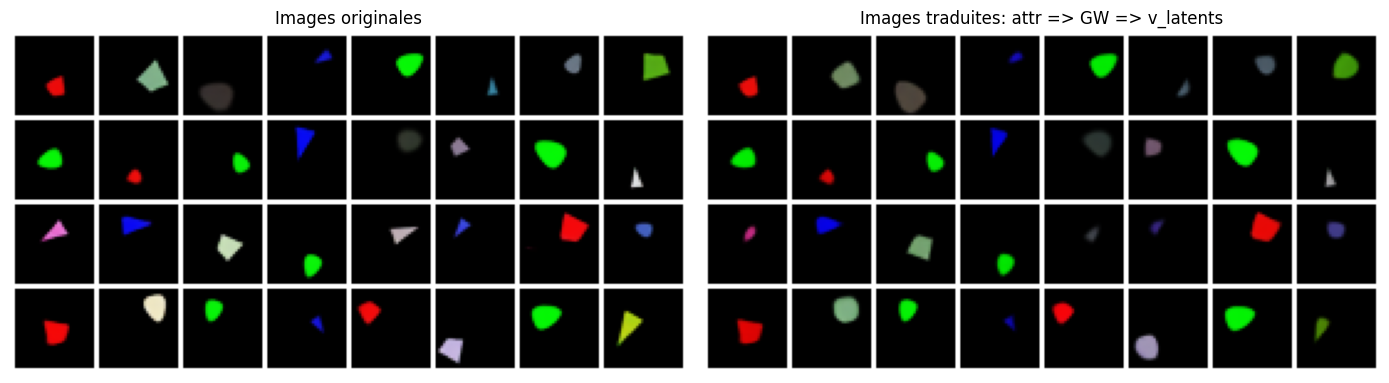

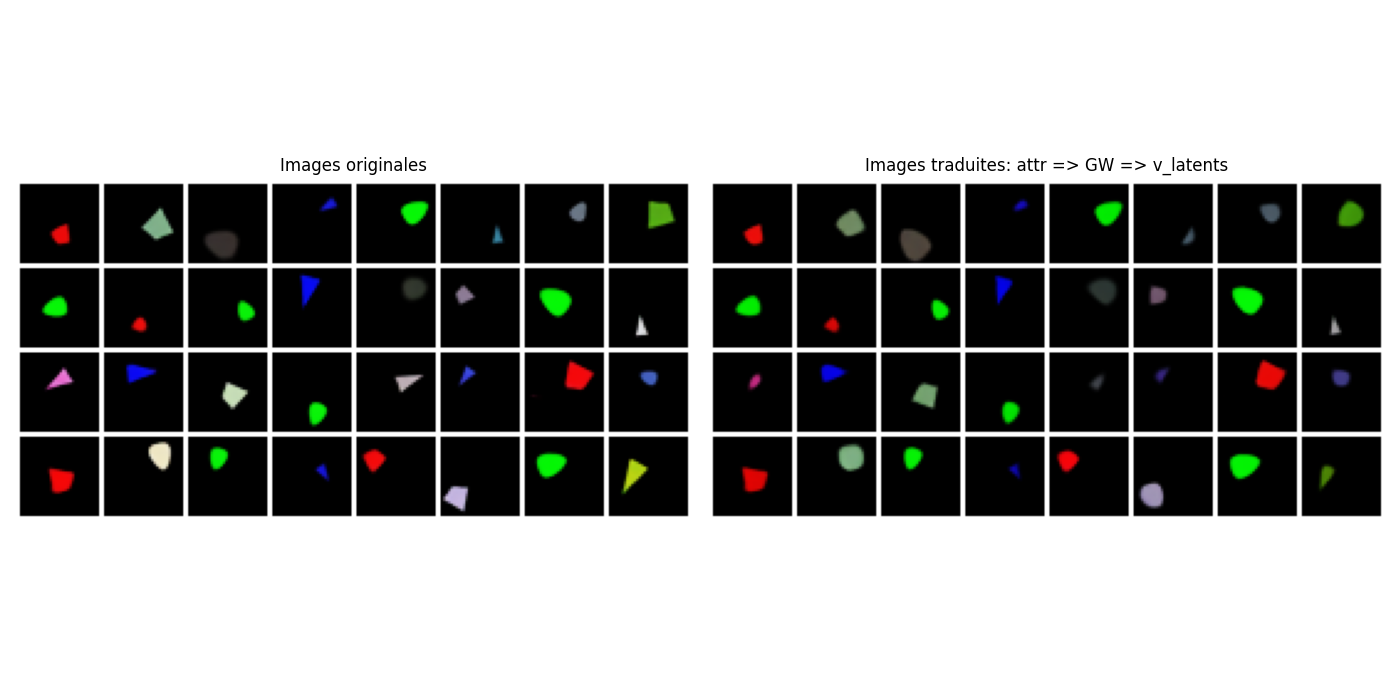

In [4]:
condition = "control"
data = "biased_50"
switch_epoch = 0
checkpoint_epoch = 0

n_samples = 32
show_results_fusion = True
fusion_attr_weight = 1.0
noise = 0.0

project_name = "syn"
experiment_name = get_experiment_name(condition, data, switch_epoch)


training_params = get_training_params(project_name, experiment_name)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

global_workspace = get_global_workspace(project_name, experiment_name, epoch=checkpoint_epoch)
data_module = get_data_module(project_name,  experiment_name)
train_samples = get_data_samples(data_module, n_samples, noise=  noise)
data_translated = get_data_translated(global_workspace, train_samples, n_samples, fusion_attr_weight, show_results_fusion)

print(data_translated["train_attr"][0:3])
print(data_translated["attr_decoded"][0:3])
plot_original_translated_comparison(data_translated["train_images"], data_translated["images_decoded"])

In [ ]:
@interact(
    cat=["Triangle", "Egg", "Diamond"],
    x=(0, 1, 0.1),
    y=(0, 1, 0.1),
    rot=(0, 1, 0.1),
    size=(0, 1, 0.1),
    color_r=(0, 1, 0.1),
    color_g=(0, 1, 0.1),
    color_b=(0, 1, 0.1),
)
def play_with_gw(
    cat: str = "Triangle",
    x: float = 0.5,
    y: float = 0.5,
    rot: float = 0.5,
    size: float = 0.5,
    color_r: float = 1,
    color_g: float = 0,
    color_b: float = 0,
):
    original_image = get_image(cat, x, y, size, rot, color_r, color_g, color_b)
    decoded_image = get_decoded_image(cat, x, y, size, rot, color_r, color_g, color_b, training_params, device, global_workspace)
    plot_interactive(original_image, decoded_image)



interactive(children=(Dropdown(description='cat', options=('Triangle', 'Egg', 'Diamond'), value='Triangle'), F…